# Визуальный анализ: какие изображения «видит» каждая зона коры

Три вопроса, от мозга к модели:

1. **Согласованность между людьми** — представление каких картинок наиболее похоже у всех
   8 испытуемых, в каждой зоне? (чистая нейронаука, модели не участвуют)
2. **Носители соответствия** — какие картинки дают наибольший вклад в согласие геометрий
   модель ↔ зона?
3. **Категорийный портрет** — какими категориями COCO обогащены «любимые» картинки каждой
   зоны, и держится ли рост `lateral` через LLM-стек без картинок с людьми
   (проверяемое предсказание из Discussion драфта)?

Метрика вклада картинки *i*: ковариация её строки в ранговой RDM модели со строкой в
ранговой RDM мозга (усреднённой по испытуемым) — «насколько пары с участием этой картинки
согласованы между двумя геометриями».


In [1]:
import json, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "cache").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

from scipy.spatial.distance import squareform
from scipy.stats import rankdata, wilcoxon

from nsd_rsa.config import load_config, resolve_paths
from nsd_rsa.design import load_expdesign, usable_images
from nsd_rsa.loaders import average_repeats, common_valid_vertices, load_subject
from nsd_rsa.noise_ceiling import normalise_to_ceiling
from nsd_rsa.rdm import compare_rdms, compute_rdm

cfg = load_config(str(ROOT / "configs" / "vlm.yaml"))
paths = resolve_paths(cfg)
design = load_expdesign(paths["meta"] / "nsd_expdesign.mat")
idx = usable_images(cfg["stimuli"]["subjects"], design, cfg["stimuli"]["min_repeats"])
valid = common_valid_vertices(paths["betas"], paths["cache"] / "valid_vertices.npy")
CEIL = {k: v[0] for k, v in json.loads((ROOT / "cache" / "rsa_results.json").read_text())["ceilings"].items()}

ROIS = ["early", "midventral", "ventral", "lateral"]
BRAIN = {}
for p in sorted(paths["betas"].glob("*_shared_betas.h5")):
    d = load_subject(p)
    for roi in ROIS:
        patt, _ = average_repeats(d, images=idx, roi=roi, valid=valid)
        BRAIN.setdefault(roi, {})[d.subject] = compute_rdm(patt.astype(np.float64))
    del d
SUBJECTS = sorted(BRAIN["early"])

IMAGES = np.load(paths["stimuli"] / "shared1000_images.npy", mmap_mode="r")[idx]
CATS = np.load(ROOT / "cache" / "coco_categories.npz")
ACTS = np.load(ROOT / "cache" / "f1_readouts_qwen2vl_2b.npz")
N = len(idx)
print(f"{N} картинок · {len(SUBJECTS)} испытуемых · зоны: {ROIS}")

515 картинок · 8 испытуемых · зоны: ['early', 'midventral', 'ventral', 'lateral']


In [2]:
def grid(indices, title, per_row=10):
    rows = int(np.ceil(len(indices) / per_row))
    fig, axes = plt.subplots(rows, per_row, figsize=(per_row * 1.5, rows * 1.55))
    for ax, i in zip(np.ravel(axes), list(indices) + [None] * 99):
        ax.axis("off")
        if i is not None:
            ax.imshow(IMAGES[i])
    fig.suptitle(title, y=1.0, fontsize=11)
    plt.tight_layout(); plt.show()


def rank_sq(condensed):
    return squareform(rankdata(condensed))


def row_contrib(m_sq, b_sq):
    """Вклад каждой картинки: ковариация её строк в двух ранговых RDM."""
    mc, bc = m_sq - m_sq.mean(), b_sq - b_sq.mean()
    return (mc * bc).sum(1)

## 1. Согласованность между людьми: что все мозги видят одинаково

Для каждой картинки — средняя корреляция её RDM-строки между всеми парами испытуемых.
Высокая = картинка занимает одно и то же место в геометрии зоны у всех восьмерых.


In [3]:
CONSIST = {}
for roi in ROIS:
    rows = np.stack([rank_sq(BRAIN[roi][s]) for s in SUBJECTS])  # (8, N, N)
    rows = (rows - rows.mean(2, keepdims=True)) / (rows.std(2, keepdims=True) + 1e-12)
    sim = np.einsum("sij,tij->sti", rows, rows) / rows.shape[2]  # (8, 8, N)
    iu = np.triu_indices(len(SUBJECTS), 1)
    CONSIST[roi] = sim[iu].mean(0)
    print(f"{roi:<12} межсубъектная согласованность: mean={CONSIST[roi].mean():.3f}, "
          f"диапазон [{CONSIST[roi].min():.3f}, {CONSIST[roi].max():.3f}]")

early        межсубъектная согласованность: mean=0.524, диапазон [0.307, 0.762]


midventral   межсубъектная согласованность: mean=0.339, диапазон [0.144, 0.536]


ventral      межсубъектная согласованность: mean=0.395, диапазон [0.169, 0.664]


lateral      межсубъектная согласованность: mean=0.288, диапазон [0.081, 0.608]


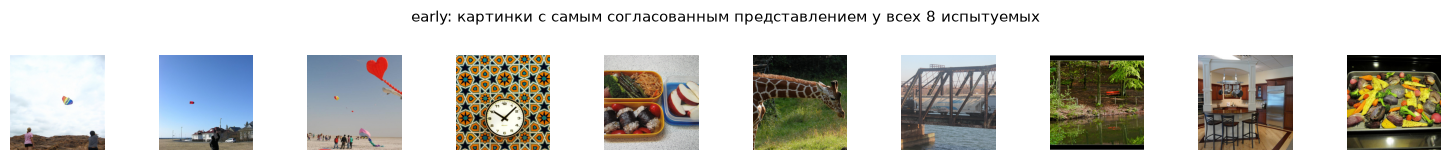

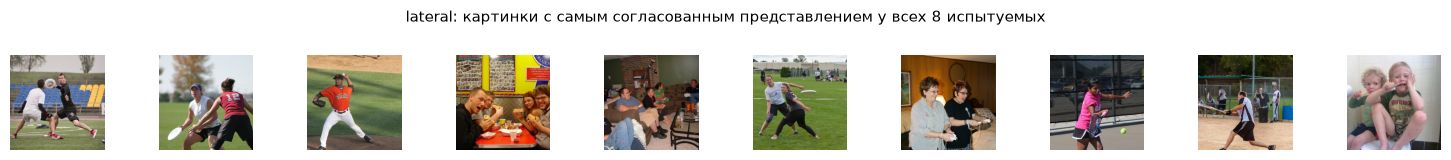

In [4]:
for roi in ["early", "lateral"]:
    top = np.argsort(CONSIST[roi])[::-1][:10]
    grid(top, f"{roi}: картинки с самым согласованным представлением у всех 8 испытуемых")

## 2. Носители соответствия модель ↔ зона

Для каждой зоны берём релевантную глубину Qwen2-VL (у `early` — пик в vision-башне,
у `lateral` — последний слой LLM, где RSA-профиль зоны выходит на максимум) и смотрим,
какие картинки несут согласие геометрий, а какие ему мешают.


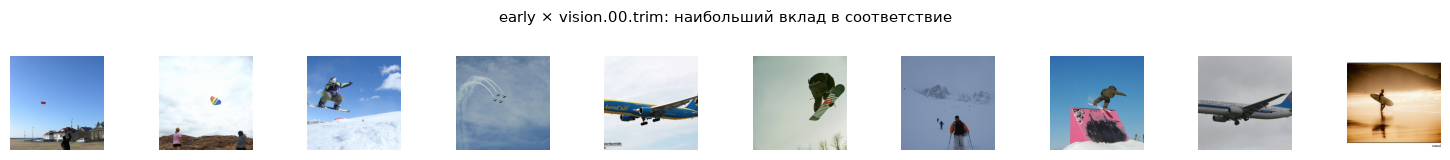

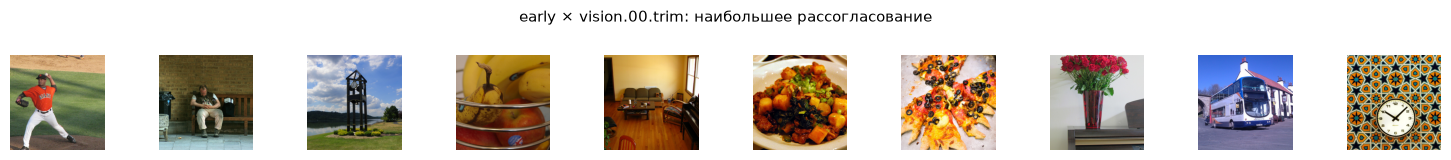

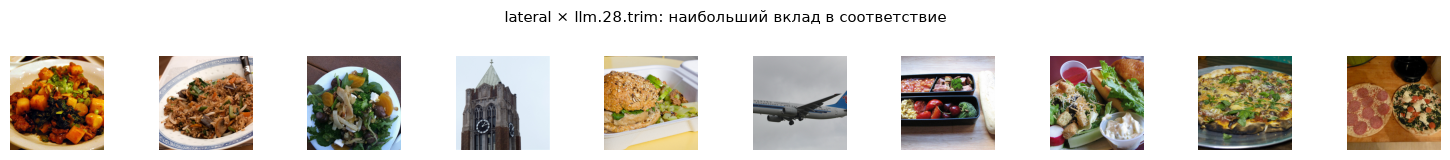

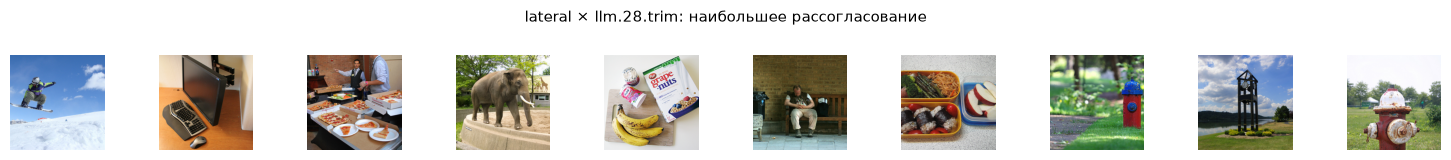

In [5]:
DEPTH = {"early": "vision.00.trim", "midventral": "vision.25.trim",
         "ventral": "vision.25.trim", "lateral": "llm.28.trim"}
CONTRIB = {}
for roi in ROIS:
    m_sq = rank_sq(compute_rdm(ACTS[DEPTH[roi]].astype(np.float64)))
    b_sq = rank_sq(np.mean([BRAIN[roi][s] for s in SUBJECTS], axis=0))
    CONTRIB[roi] = row_contrib(m_sq, b_sq)

for roi in ["early", "lateral"]:
    order_i = np.argsort(CONTRIB[roi])[::-1]
    grid(order_i[:10], f"{roi} × {DEPTH[roi]}: наибольший вклад в соответствие")
    grid(order_i[-10:], f"{roi} × {DEPTH[roi]}: наибольшее рассогласование")

## 3. Категорийный портрет зон

Корреляция (точечно-бисериальная) вклада картинки с присутствием каждой категории COCO:
положительная = картинки с этой категорией систематически несут соответствие.


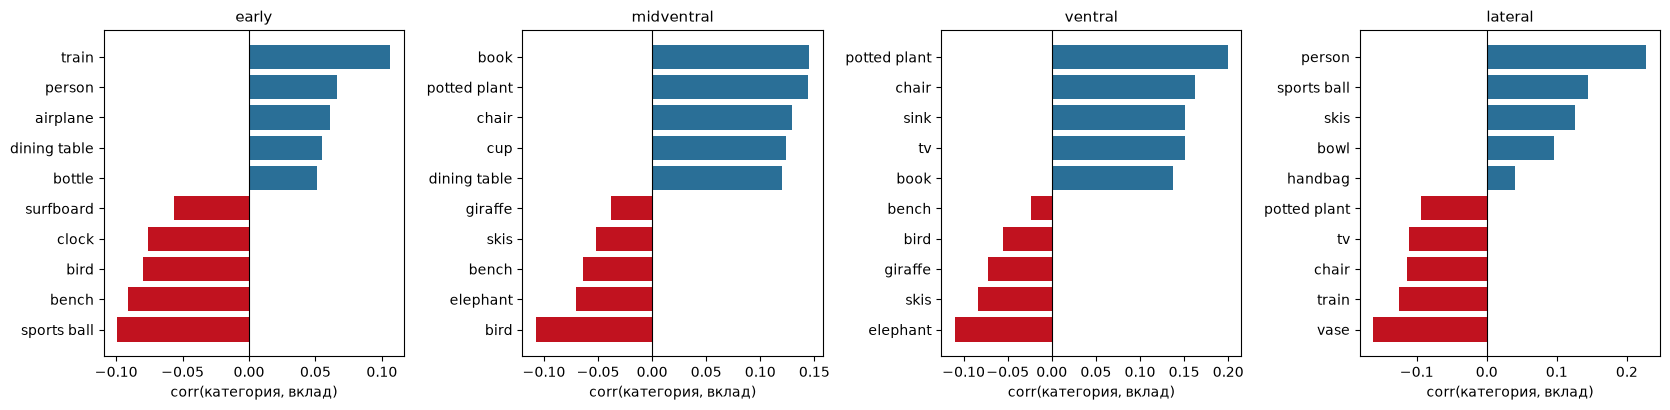

person: prevalence = 0.41


In [6]:
# имена категорий COCO в порядке колонок multihot (по возрастанию category_id)
blob = json.loads((paths["meta"] / "coco" / "annotations" / "instances_val2017.json")
                  .read_text(encoding="utf-8"))
id2name = {c["id"]: c["name"] for c in blob["categories"]}
cat_ids = sorted(id2name)
names = [id2name[c] for c in cat_ids]
hot = CATS["multihot"]
common = hot.mean(0) >= 0.03

fig, axes = plt.subplots(1, len(ROIS), figsize=(4.2 * len(ROIS), 4.2))
ENRICH = {}
for ax, roi in zip(axes, ROIS):
    c = CONTRIB[roi]
    corr = np.array([np.corrcoef(hot[:, j], c)[0, 1] if common[j] else np.nan
                     for j in range(hot.shape[1])])
    ENRICH[roi] = pd.Series(corr, index=names).dropna().sort_values()
    show = pd.concat([ENRICH[roi].head(5), ENRICH[roi].tail(5)])
    ax.barh(show.index, show.values,
            color=["#c1121f" if v < 0 else "#2a6f97" for v in show.values])
    ax.axvline(0, color="k", lw=.8); ax.set_title(roi, fontsize=11)
    ax.set_xlabel("corr(категория, вклад)")
plt.tight_layout(); plt.show()
print("person: prevalence =", f"{hot[:, names.index('person')].mean():.2f}")

## 4. Живой тест предсказания: рост `lateral` без людей

Интерпретация «латеральный поток — про агентов» предсказывает, что рост соответствия
через LLM-стек должен нестись картинками с людьми. Проверяем в лоб: пересчитываем
наклон по слоям LLM (Qwen2-VL) на двух подмножествах стимулов — только с людьми и
только без — для каждого испытуемого.


In [7]:
person = hot[:, names.index("person")].astype(bool)
print(f"с людьми: {person.sum()} картинок, без: {(~person).sum()}")

llm_keys = sorted((k for k in ACTS.files if k.startswith("llm.") and k.endswith(".trim")),
                  key=lambda k: int(k.split(".")[1]))
model_sq = {k: squareform(compute_rdm(ACTS[k].astype(np.float64))) for k in llm_keys}

def subset_slopes(mask, roi):
    sel = np.where(mask)[0]
    out = []
    for s in SUBJECTS:
        b = squareform(BRAIN[roi][s])[np.ix_(sel, sel)]
        b_c = squareform(b, checks=False)
        y = [normalise_to_ceiling(
                compare_rdms(squareform(model_sq[k][np.ix_(sel, sel)], checks=False), b_c),
                CEIL[roi]) for k in llm_keys]
        out.append(np.polyfit(np.arange(len(y)), y, 1)[0] * 100)
    return np.array(out)

rows = []
for roi in ["early", "lateral"]:
    for label, mask in [("все 515", np.ones(N, bool)), ("только с людьми", person),
                        ("только без людей", ~person)]:
        sl = subset_slopes(mask, roi)
        rows.append({"зона": roi, "подмножество": label, "наклон×100": sl.mean(),
                     "рост у": f"{(sl>0).sum()}/8", "p": wilcoxon(sl).pvalue})
pd.DataFrame(rows).set_index(["зона", "подмножество"]).round(3)

с людьми: 213 картинок, без: 302


наклон×100 рост у      p
зона    подмножество                              
early   все 515               -0.901    0/8  0.008
        только с людьми       -1.254    0/8  0.008
        только без людей      -0.741    0/8  0.008
lateral все 515                0.466    8/8  0.008
        только с людьми        0.227    7/8  0.039
        только без людей       0.075    5/8  0.547

## Как это читать

- **§1** — «правильный ответ природы»: у ранней коры согласованность несут картинки с
  выраженной низкоуровневой структурой, у латеральной — сцены с агентами и действием.
- **§2** — какие стимулы несут наше соответствие модель↔мозг (и какие ему мешают —
  посмотрите на «рассогласующие» сетки, там часто виден систематический паттерн).
- **§3** — категорийные портреты зон; `person` в `lateral` — ключевая строка.
- **§4** — прямой тест: если наклон `lateral` выживает и «без людей», интерпретацию надо
  формулировать шире, чем «люди в кадре»; если нет — предсказание подтверждено буквально.
  Любой исход информативен и идёт в Discussion.
